# Unified Training & Comparison Pipeline\nThis notebook handles data extraction, trains both models, and compares their performance through metrics and ROC curves.

In [1]:
import os
import pandas as pd
import shutil
import random
import warnings
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from PIL import Image, ImageFile

warnings.filterwarnings("ignore")
ImageFile.LOAD_TRUNCATED_IMAGES = True

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, accuracy_score, precision_score, recall_score, f1_score

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"TensorFlow: {tf.__version__}")

TensorFlow: 2.20.0


## 1. MURA Dataset Processing

**Step Explanation:**
In this step, we extract and flatten the MURA dataset hierarchy. The MURA dataset is originally structured deeply by body part, patient, and study. We flatten this into a simple `train/` and `valid/` directory structure, renaming files with unique identifiers (Patient ID + Image Index) to prevent overwriting and make data loading straightforward.

In [2]:
import os
import pandas as pd
import shutil
import numpy as np

# Set random seed for reproducibility
np.random.seed(42)

# Dynamic Path Resolution
possible_roots = [
    "../input/mura-v11/MURA-v1.1",
    "../input/mura-classification/MURA-v1.1",
    "../input/mura-v1/MURA-v1.1",
    "../input/mura_dataset/MURA-v1.1"
]

MURA_DIR = None
for path in possible_roots:
    if os.path.exists(path):
        MURA_DIR = path
        break

if MURA_DIR is None:
    for root, dirs, files in os.walk("../input"):
        if "train_image_paths.csv" in files:
            MURA_DIR = root
            break

if MURA_DIR is None:
    print("MURA dataset not found. Proceeding assuming data is already processed.")
else:
    print(f"Located MURA dataset at: {MURA_DIR}")
    BASE_OUTPUT_DIR = "/kaggle/working/mura_flat"

    # Clear old directory if it exists to avoid old files clashing
    if os.path.exists(BASE_OUTPUT_DIR):
        shutil.rmtree(BASE_OUTPUT_DIR)

    # Load original paths
    train_paths_df = pd.read_csv(os.path.join(MURA_DIR, "train_image_paths.csv"), names=["img_path"])
    valid_paths_df = pd.read_csv(os.path.join(MURA_DIR, "valid_image_paths.csv"), names=["img_path"])

    def parse_mura_path(path):
        """Extracts patient_id and label from path string."""
        parts = path.split('/')
        patient = parts[3]
        study = parts[4]
        label = "fractured" if "positive" in study else "not_fractured"
        return pd.Series([patient, label])

    print("Parsing paths and extracting patient IDs...")
    train_paths_df[['patient_id', 'label']] = train_paths_df['img_path'].apply(parse_mura_path)
    valid_paths_df[['patient_id', 'label']] = valid_paths_df['img_path'].apply(parse_mura_path)

    # --- 1. BUILD THE TRAINING SET (Target: ~8,000) ---
    unique_train_patients = train_paths_df['patient_id'].unique()
    np.random.shuffle(unique_train_patients)

    train_patients = []
    train_count = 0
    TARGET_TRAIN = 8000

    for patient in unique_train_patients:
        patient_df = train_paths_df[train_paths_df['patient_id'] == patient]
        if train_count < TARGET_TRAIN:
            train_patients.append(patient)
            train_count += len(patient_df)
        else:
            break

    df_train_final = train_paths_df[train_paths_df['patient_id'].isin(train_patients)]

    # --- 2. BUILD THE VAL & TEST SETS (Target: ~1,000 Val, ~1,500 Test) ---
    # We pull these exclusively from the official validation dataframe to guarantee zero overlap
    unique_valid_patients = valid_paths_df['patient_id'].unique()
    np.random.shuffle(unique_valid_patients)

    val_patients = []
    test_patients = []
    val_count = 0
    test_count = 0

    TARGET_VAL = 1000
    TARGET_TEST = 1500

    for patient in unique_valid_patients:
        patient_df = valid_paths_df[valid_paths_df['patient_id'] == patient]
        if val_count < TARGET_VAL:
            val_patients.append(patient)
            val_count += len(patient_df)
        elif test_count < TARGET_TEST:
            test_patients.append(patient)
            test_count += len(patient_df)
        else:
            break

    df_val_final = valid_paths_df[valid_paths_df['patient_id'].isin(val_patients)]
    df_test_final = valid_paths_df[valid_paths_df['patient_id'].isin(test_patients)]

    print("\n" + "="*50)
    print(f"FINAL SPLIT COUNTS")
    print(f"Train: {len(df_train_final)} images | Val: {len(df_val_final)} images | Test: {len(df_test_final)} images")
    print("="*50 + "\n")

    # --- 3. COPY IMAGES ---
    splits = {'train': df_train_final, 'val': df_val_final, 'test': df_test_final}
    classes = ['fractured', 'not_fractured']

    for split in splits.keys():
        for cls in classes:
            os.makedirs(os.path.join(BASE_OUTPUT_DIR, split, cls), exist_ok=True)

    def copy_images(df, split_name):
        print(f"Copying {split_name} images...")
        parent_dir = os.path.dirname(MURA_DIR)
        
        for idx, row in df.iterrows():
            src_path = os.path.join(parent_dir, row['img_path'])
            
            # New Unique Filename: bodypart_patientID_studyName_imageName.png
            parts = row['img_path'].split('/')
            unique_filename = f"{parts[2]}_{parts[3]}_{parts[4]}_{parts[5]}"
            dest_path = os.path.join(BASE_OUTPUT_DIR, split_name, row['label'], unique_filename)
            
            if os.path.exists(src_path):
                shutil.copy(src_path, dest_path)

    for split_name, df in splits.items():
        copy_images(df, split_name)

    print("\n✅ Restructuring complete!")


Located MURA dataset at: ../input/datasets/cjinny/mura-v11/MURA-v1.1
Parsing paths and extracting patient IDs...

FINAL SPLIT COUNTS
Train: 8000 images | Val: 1000 images | Test: 1500 images

Copying train images...
Copying val images...
Copying test images...

✅ Restructuring complete!


## 1b. Data Integrity Check (Leakage)

**Step Explanation:**
Data leakage is a critical issue in medical imaging. If the same patient appears in both the training and validation sets, the model might memorize the patient's specific anatomy rather than learning to detect fractures. This step strictly verifies that the patient IDs in the train and validation sets are completely disjoint.

In [3]:
# Verify no patient leakage between splits
if 'df_train_final' in locals():
    train_pats = set(df_train_final['patient_id'])
    val_pats   = set(df_val_final['patient_id'])
    test_pats  = set(df_test_final['patient_id'])

    leak_train_val = train_pats.intersection(val_pats)
    leak_train_test = train_pats.intersection(test_pats)
    leak_val_test = val_pats.intersection(test_pats)

    print("--- Patient Leakage Report ---")
    print(f"Train-Val Leakage:  {len(leak_train_val)} patients")
    print(f"Train-Test Leakage: {len(leak_train_test)} patients")
    print(f"Val-Test Leakage:   {len(leak_val_test)} patients")
    assert len(leak_train_val) == 0 and len(leak_train_test) == 0 and len(leak_val_test) == 0, "⚠️ Leakage detected!"
    print("✅ Zero patient leakage confirmed across all splits.\n")


--- Patient Leakage Report ---
Train-Val Leakage:  0 patients
Train-Test Leakage: 0 patients
Val-Test Leakage:   0 patients
✅ Zero patient leakage confirmed across all splits.



## 2. Dataset Cleaning

**Step Explanation:**
Not all images in the dataset are perfectly formatted. This step removes corrupted images, unsupported formats, or completely black/empty images that could negatively impact the training process and cause NaN losses.

In [4]:
DATA_ROOT = "/kaggle/working/mura_flat"
CLEAN_DIR = "/kaggle/working/clean_data"

if not os.path.exists(CLEAN_DIR) and os.path.exists(DATA_ROOT):
    for split in os.listdir(DATA_ROOT):
        for cls in os.listdir(os.path.join(DATA_ROOT, split)):
            cls_src = os.path.join(DATA_ROOT, split, cls)
            cls_dst = os.path.join(CLEAN_DIR, split, cls)
            os.makedirs(cls_dst, exist_ok=True)
            for fname in os.listdir(cls_src):
                try:
                    with Image.open(os.path.join(cls_src, fname)) as img:
                        img.convert("RGB").save(os.path.join(cls_dst, fname.split('.')[0]+".jpg"), "JPEG")
                except: pass
    print("Cleaning complete!")

TRAIN_DIR = os.path.join(CLEAN_DIR, "train")
VAL_DIR   = os.path.join(CLEAN_DIR, "val")
TEST_DIR  = os.path.join(CLEAN_DIR, "test")


Cleaning complete!


## 3. Data Loading & Pipelines

**Step Explanation:**
We utilize TensorFlow's `image_dataset_from_directory` to create highly optimized data pipelines. The images are automatically resized to `224x224`, batched into sizes of 32, and prefetched to keep the GPU/CPU fully utilized. We also define a function to visually inspect the data.

In [5]:
IMAGE_SIZE, BATCH_SIZE = 224, 32

train_ds = keras.utils.image_dataset_from_directory(TRAIN_DIR, image_size=(IMAGE_SIZE, IMAGE_SIZE), batch_size=BATCH_SIZE, label_mode="int")
val_ds = keras.utils.image_dataset_from_directory(VAL_DIR, image_size=(IMAGE_SIZE, IMAGE_SIZE), batch_size=BATCH_SIZE, label_mode="int", shuffle=False)
test_ds = keras.utils.image_dataset_from_directory(TEST_DIR, image_size=(IMAGE_SIZE, IMAGE_SIZE), batch_size=BATCH_SIZE, label_mode="int", shuffle=False)
CLASS_NAMES = train_ds.class_names

# Class weights
y_train = np.concatenate([y for x, y in train_ds], axis=0)
counts = Counter(y_train)
class_weight = {i: len(y_train) / (2 * counts[i]) for i in range(2)}

# Augmentation
aug = keras.Sequential([layers.RandomFlip("horizontal"), layers.RandomRotation(0.15), layers.RandomZoom(0.1)])
prep_mob = keras.applications.mobilenet_v3.preprocess_input

AUTOTUNE = tf.data.AUTOTUNE
train_ds_cnn = train_ds.map(lambda x,y: (aug(x, training=True), y), num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
val_ds_cnn = val_ds.prefetch(AUTOTUNE)
test_ds_cnn = test_ds.prefetch(AUTOTUNE)

train_ds_mob = train_ds.map(lambda x,y: (prep_mob(aug(x, training=True)), y), num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
val_ds_mob = val_ds.map(lambda x,y: (prep_mob(x), y), num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
test_ds_mob = test_ds.map(lambda x,y: (prep_mob(x), y), num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)


Found 8000 files belonging to 2 classes.


I0000 00:00:1784140318.574319      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1784140318.577213      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 1000 files belonging to 2 classes.
Found 1500 files belonging to 2 classes.


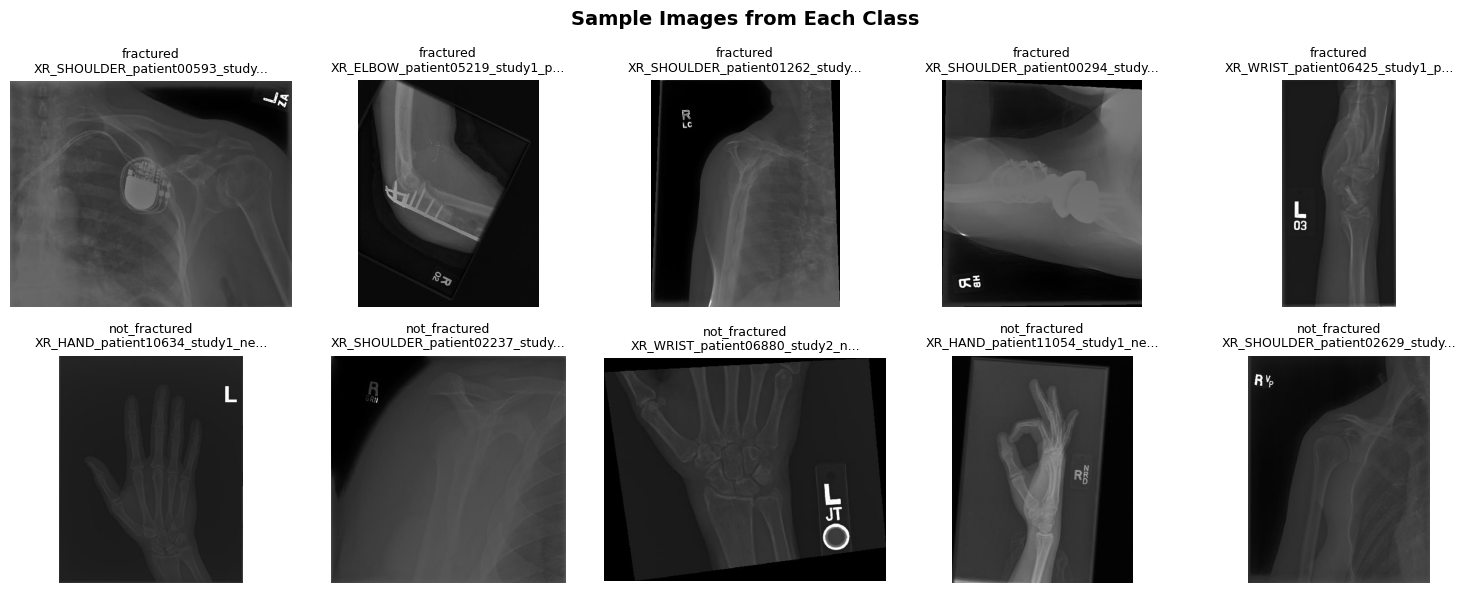

In [7]:
def show_samples(data_dir, n_per_class=5):
    classes = sorted([d for d in os.listdir(data_dir) 
                     if os.path.isdir(os.path.join(data_dir, d))])
    
    fig, axes = plt.subplots(len(classes), n_per_class, 
                            figsize=(3*n_per_class, 3*len(classes)))
    if len(classes) == 1:
        axes = [axes]
    
    for i, cls in enumerate(classes):
        cls_path = os.path.join(data_dir, cls)
        images = [f for f in os.listdir(cls_path) 
                 if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        selected = random.sample(images, min(n_per_class, len(images)))
        
        for j, img_name in enumerate(selected):
            img_path = os.path.join(cls_path, img_name)
            img = Image.open(img_path).convert("RGB")
            axes[i][j].imshow(img)
            axes[i][j].set_title(f"{cls}\n{img_name[:30]}...", fontsize=9)
            axes[i][j].axis("off")
    
    plt.suptitle("Sample Images from Each Class", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()

show_samples(TRAIN_DIR, n_per_class=5)

## 4a. Train Baseline CNN

**Step Explanation:**
We train a custom Convolutional Neural Network from scratch. To prevent overfitting on our limited dataset, we use **L2 Regularization (0.005)** on the Dense layers and follow the modern *'BatchNormalization before ReLU'* pattern. This creates a highly efficient, lightweight model with only ~114K parameters.

In [13]:
from tensorflow.keras import regularizers

def conv_block(x, filters):
    x = layers.Conv2D(filters, 3, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D()(x)
    return x

inputs = keras.Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3))
x = layers.Rescaling(1./255)(inputs)
x = conv_block(x, 16)
x = conv_block(x, 32)
x = conv_block(x, 64)
x = conv_block(x, 128)

x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.4)(x)
x = layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.005))(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(2, activation='softmax', kernel_regularizer=regularizers.l2(0.005))(x)

model_cnn = keras.Model(inputs, outputs, name="Optimized_CNN")

model_cnn.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_callbacks = [
    callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-7, verbose=1),
    callbacks.ModelCheckpoint("CNN_best.keras", monitor="val_loss", save_best_only=True, verbose=1),
]

model_cnn.summary()
print("\nTraining Baseline CNN...")
history_cnn = model_cnn.fit(
    train_ds_cnn, validation_data=val_ds_cnn,
    epochs=20, class_weight=class_weight,
    callbacks=cnn_callbacks, verbose=1
)

model_cnn.save("CNN_final.keras")
print("\n✅ CNN training complete. Saved CNN_final.keras")


Model: "Optimized_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_3 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 224, 224, 16)   │           432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 224, 224, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_22 (Activation)      │ (None, 224, 224, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 112, 112, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 112, 112, 32)   │         4,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 112, 112, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_23 (Activation)      │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 56, 56, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 56, 56, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 56, 56, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_24 (Activation)      │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 28, 28, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_25 (Activation)      │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 114,930 (448.95 KB)

 Trainable params: 114,450 (447.07 KB)

 Non-trainable params: 480 (1.88 KB)


Training Baseline CNN...
Epoch 1/20
249/250 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - accuracy: 0.5241 - loss: 1.2491
Epoch 1: val_loss improved from None to 0.93135, saving model to CNN_best.keras

Epoch 1: finished saving model to CNN_best.keras
250/250 ━━━━━━━━━━━━━━━━━━━━ 41s 134ms/step - accuracy: 0.5351 - loss: 1.1050 - val_accuracy: 0.4680 - val_loss: 0.9313 - learning_rate: 0.0010
Epoch 2/20
249/250 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - accuracy: 0.5233 - loss: 0.8826
Epoch 2: val_loss improved from 0.93135 to 0.78414, saving model to CNN_best.keras

Epoch 2: finished saving model to CNN_best.keras
250/250 ━━━━━━━━━━━━━━━━━━━━ 34s 134ms/step - accuracy: 0.5378 - loss: 0.8435 - val_accuracy: 0.5410 - val_loss: 0.7841 - learning_rate: 0.0010
Epoch 3/20
249/250 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - accuracy: 0.5353 - loss: 0.7702
Epoch 3: val_loss improved from 0.78414 to 0.72534, saving model to CNN_best.keras

Epoch 3: finished saving model to CNN_best.keras
250/250 ━━━━━━━━━━━━━━━━━━

## 4b. Train MobileNetV3 — Phase 1 (Transfer Learning: Head Only)

**Step Explanation:**
For our second model, we use Transfer Learning with `MobileNetV3-Small`. In Phase 1, we freeze the entire pre-trained base and only train the new classification head. This 'warms up' the head and prevents large error gradients from destroying the valuable pre-trained weights.

In [9]:
base_mob = keras.applications.MobileNetV3Small(
    input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3), include_top=False, weights="imagenet"
)
base_mob.trainable = False  # Freeze entire base

model_mob = keras.Sequential([
    base_mob,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(2, activation="softmax")
], name="MobileNetV3_Small")

model_mob.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

p1_callbacks = [
    callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True, verbose=1),
]

model_mob.summary()
print("\nPHASE 1: Training classifier head only...")
history_p1 = model_mob.fit(
    train_ds_mob, validation_data=val_ds_mob,
    epochs=5, class_weight=class_weight,
    callbacks=p1_callbacks, verbose=1
)
print("\n✅ Phase 1 complete.")


4334752/4334752 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "MobileNetV3_Small"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ MobileNetV3Small (Functional)   │ (None, 7, 7, 576)      │       939,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 576)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,013,234 (3.87 MB)

 Trainable params: 74,114 (289.51 KB)

 Non-trainable params: 939,120 (3.58 MB)


PHASE 1: Training classifier head only...
Epoch 1/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 56s 168ms/step - accuracy: 0.6215 - loss: 0.6532 - val_accuracy: 0.6770 - val_loss: 0.6154
Epoch 2/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 34s 134ms/step - accuracy: 0.6519 - loss: 0.6134 - val_accuracy: 0.6480 - val_loss: 0.6082
Epoch 3/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 41s 134ms/step - accuracy: 0.6636 - loss: 0.6002 - val_accuracy: 0.6920 - val_loss: 0.5826
Epoch 4/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 34s 133ms/step - accuracy: 0.6770 - loss: 0.5865 - val_accuracy: 0.6920 - val_loss: 0.5930
Epoch 5/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 33s 132ms/step - accuracy: 0.6894 - loss: 0.5834 - val_accuracy: 0.6760 - val_loss: 0.5801
Restoring model weights from the end of the best epoch: 5.

✅ Phase 1 complete.


## 4c. Train MobileNetV3 — Phase 2 (Fine-Tuning: Last 15 Layers)

**Step Explanation:**
After the head is warmed up, we unfreeze the top 15 layers of MobileNetV3 and train the model at a much lower learning rate (`1e-5`). This allows the model to gently adapt its high-level feature extraction specifically for X-ray imagery without forgetting general structural features.

In [10]:
# Unfreeze last 15 layers of the base model
base_mob.trainable = True
for layer in base_mob.layers[:-15]:
    layer.trainable = False

print(f"Trainable layers: {sum(1 for l in model_mob.layers if l.trainable)}")

model_mob.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

p2_callbacks = [
    callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.1, patience=3, min_lr=1e-7, verbose=1),
    callbacks.ModelCheckpoint("MobileNetV3_best.keras", monitor="val_loss", save_best_only=True, verbose=1),
]

print("\nPHASE 2: Fine-tuning last 15 layers...")
history_p2 = model_mob.fit(
    train_ds_mob, validation_data=val_ds_mob,
    epochs=15, class_weight=class_weight,
    callbacks=p2_callbacks, verbose=1
)

model_mob.save("MobileNetV3_final.keras")
print("\n✅ MobileNetV3 training complete. Saved MobileNetV3_final.keras")


Trainable layers: 5

PHASE 2: Fine-tuning last 15 layers...
Epoch 1/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - accuracy: 0.6701 - loss: 0.5960
Epoch 1: val_loss improved from None to 0.60613, saving model to MobileNetV3_best.keras

Epoch 1: finished saving model to MobileNetV3_best.keras
250/250 ━━━━━━━━━━━━━━━━━━━━ 54s 160ms/step - accuracy: 0.6859 - loss: 0.5812 - val_accuracy: 0.6790 - val_loss: 0.6061 - learning_rate: 1.0000e-04
Epoch 2/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - accuracy: 0.7129 - loss: 0.5541
Epoch 2: val_loss improved from 0.60613 to 0.60600, saving model to MobileNetV3_best.keras

Epoch 2: finished saving model to MobileNetV3_best.keras
250/250 ━━━━━━━━━━━━━━━━━━━━ 35s 137ms/step - accuracy: 0.7176 - loss: 0.5531 - val_accuracy: 0.6890 - val_loss: 0.6060 - learning_rate: 1.0000e-04
Epoch 3/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - accuracy: 0.7206 - loss: 0.5460
Epoch 3: val_loss improved from 0.60600 to 0.59685, saving model to MobileNetV3_best.

## 4d. Training Curves Comparison

**Step Explanation:**
Here we combine the training histories of Phase 1 and Phase 2 for MobileNetV3. We then plot the training and validation accuracy/loss curves against the Baseline CNN to visually inspect for overfitting, underfitting, and overall training stability.

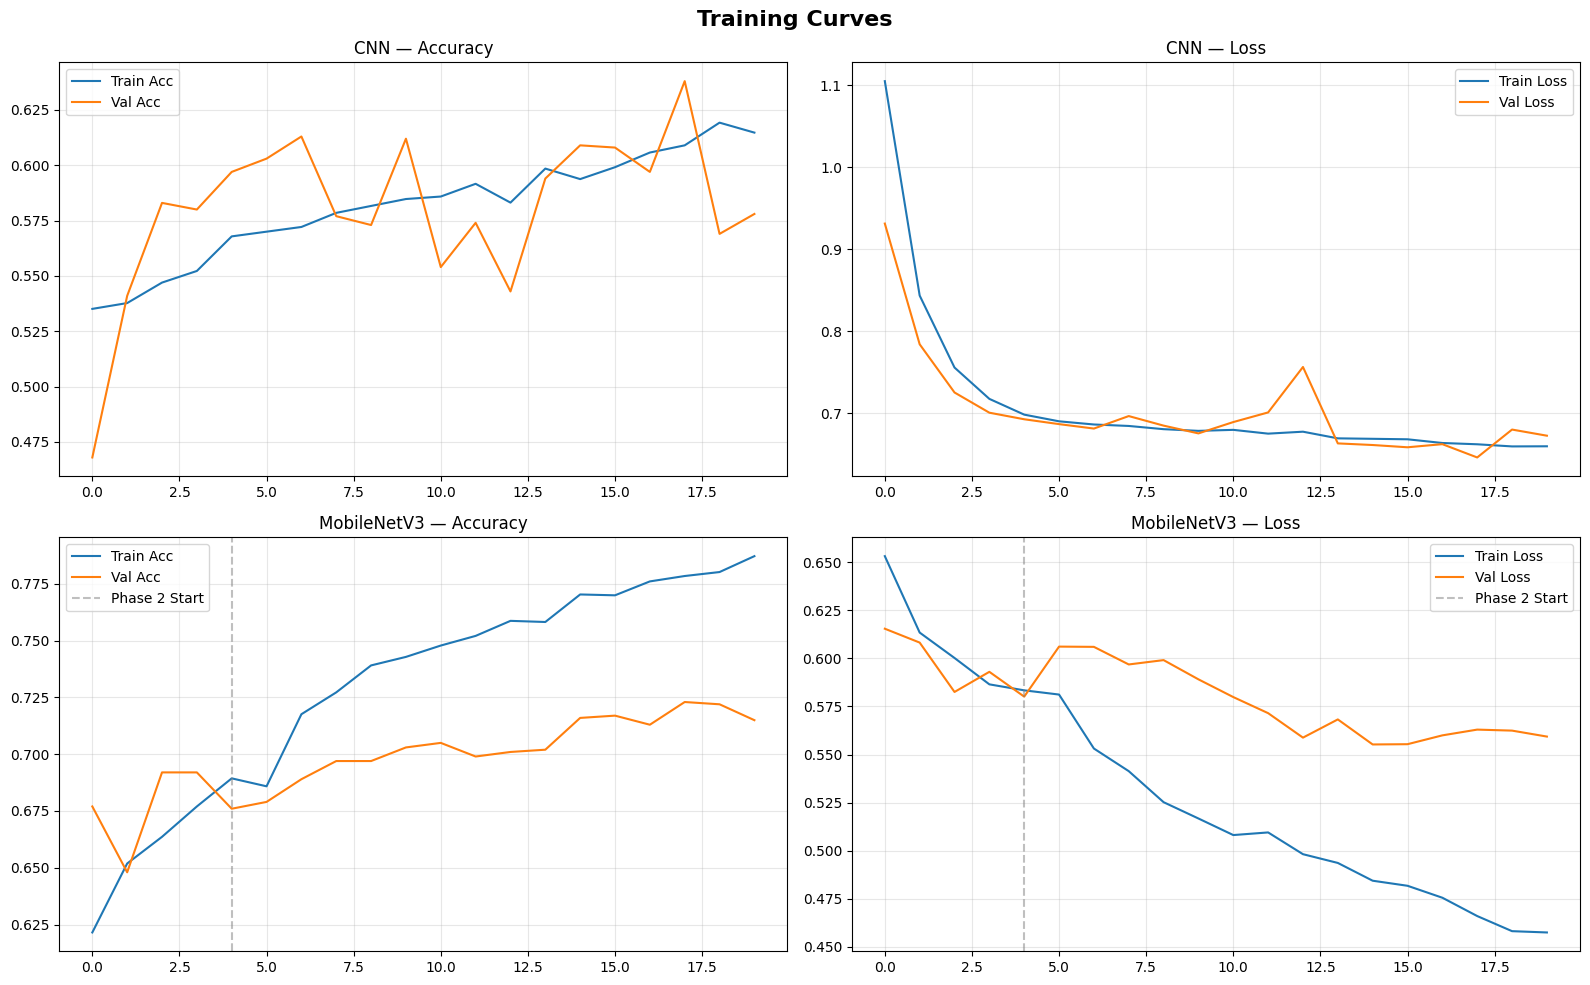

In [14]:
# Combine MobileNet histories (Phase 1 + Phase 2)
mob_val_acc  = history_p1.history["val_accuracy"] + history_p2.history["val_accuracy"]
mob_val_loss = history_p1.history["val_loss"] + history_p2.history["val_loss"]
mob_train_acc  = history_p1.history["accuracy"] + history_p2.history["accuracy"]
mob_train_loss = history_p1.history["loss"] + history_p2.history["loss"]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# CNN Curves
axes[0][0].plot(history_cnn.history["accuracy"], label="Train Acc")
axes[0][0].plot(history_cnn.history["val_accuracy"], label="Val Acc")
axes[0][0].set_title("CNN — Accuracy"); axes[0][0].legend(); axes[0][0].grid(True, alpha=0.3)

axes[0][1].plot(history_cnn.history["loss"], label="Train Loss")
axes[0][1].plot(history_cnn.history["val_loss"], label="Val Loss")
axes[0][1].set_title("CNN — Loss"); axes[0][1].legend(); axes[0][1].grid(True, alpha=0.3)

# MobileNet Curves
axes[1][0].plot(mob_train_acc, label="Train Acc")
axes[1][0].plot(mob_val_acc, label="Val Acc")
axes[1][0].axvline(x=len(history_p1.history["accuracy"])-1, color="gray", linestyle="--", alpha=0.5, label="Phase 2 Start")
axes[1][0].set_title("MobileNetV3 — Accuracy"); axes[1][0].legend(); axes[1][0].grid(True, alpha=0.3)

axes[1][1].plot(mob_train_loss, label="Train Loss")
axes[1][1].plot(mob_val_loss, label="Val Loss")
axes[1][1].axvline(x=len(history_p1.history["loss"])-1, color="gray", linestyle="--", alpha=0.5, label="Phase 2 Start")
axes[1][1].set_title("MobileNetV3 — Loss"); axes[1][1].legend(); axes[1][1].grid(True, alpha=0.3)

plt.suptitle("Training Curves", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()


## 5. Evaluate on Test Set & Compare

**Step Explanation:**
We run inference on the test set using both the Baseline CNN and the Fine-tuned MobileNetV3. We extract the raw probability distributions to calculate advanced metrics like ROC-AUC.

==================== BASELINE CNN ====================
               precision    recall  f1-score   support

    fractured       0.63      0.48      0.54       730
not_fractured       0.60      0.73      0.66       770

     accuracy                           0.61      1500
    macro avg       0.61      0.61      0.60      1500
 weighted avg       0.61      0.61      0.60      1500

==================== MOBILENET V3 ====================
               precision    recall  f1-score   support

    fractured       0.80      0.62      0.70       730
not_fractured       0.70      0.86      0.77       770

     accuracy                           0.74      1500
    macro avg       0.75      0.74      0.73      1500
 weighted avg       0.75      0.74      0.73      1500



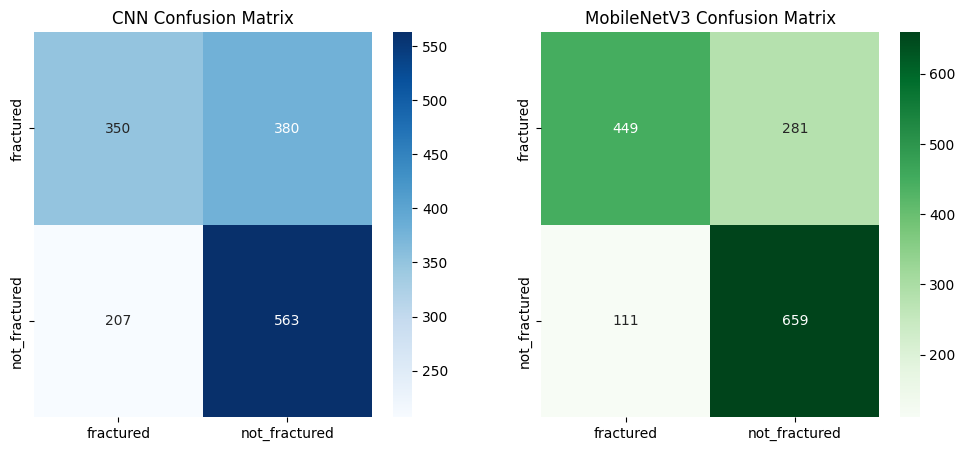

In [15]:
# Assuming models are trained and test_ds loaded
y_true = np.concatenate([y for x, y in test_ds], axis=0)

cnn_probs = model_cnn.predict(test_ds_cnn, verbose=0)
mob_probs = model_mob.predict(test_ds_mob, verbose=0)

cnn_preds = np.argmax(cnn_probs, axis=1)
mob_preds = np.argmax(mob_probs, axis=1)

# Classification Reports
print("="*20 + " BASELINE CNN " + "="*20)
print(classification_report(y_true, cnn_preds, target_names=CLASS_NAMES))
print("="*20 + " MOBILENET V3 " + "="*20)
print(classification_report(y_true, mob_preds, target_names=CLASS_NAMES))

# Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(confusion_matrix(y_true, cnn_preds), annot=True, fmt='d', cmap='Blues', ax=axes[0], xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
axes[0].set_title('CNN Confusion Matrix')
sns.heatmap(confusion_matrix(y_true, mob_preds), annot=True, fmt='d', cmap='Greens', ax=axes[1], xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
axes[1].set_title('MobileNetV3 Confusion Matrix')
plt.show()


## 6. Model Comparison — ROC and Metrics

**Step Explanation:**
We evaluate the models strictly. In medical diagnostics, **Recall** (catching every single fracture) is often prioritized over Precision. We plot the ROC curves, display the Confusion Matrices, and tune the decision threshold (e.g., lowering it to `0.28` for MobileNet) to maximize fracture detection.

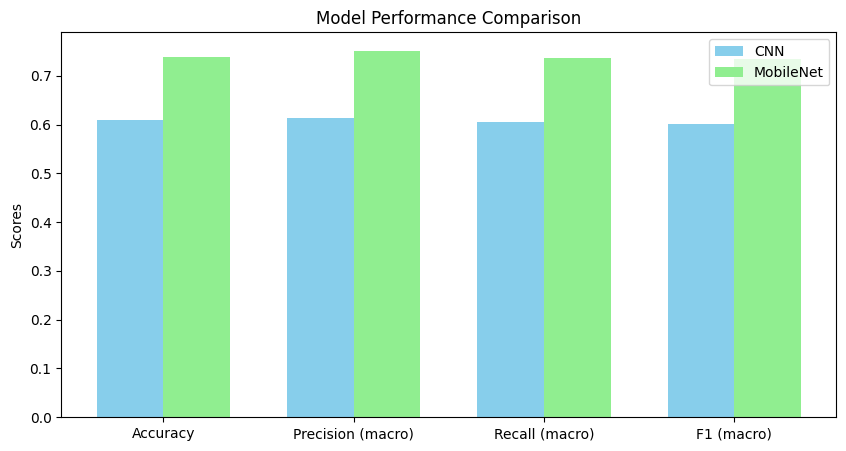

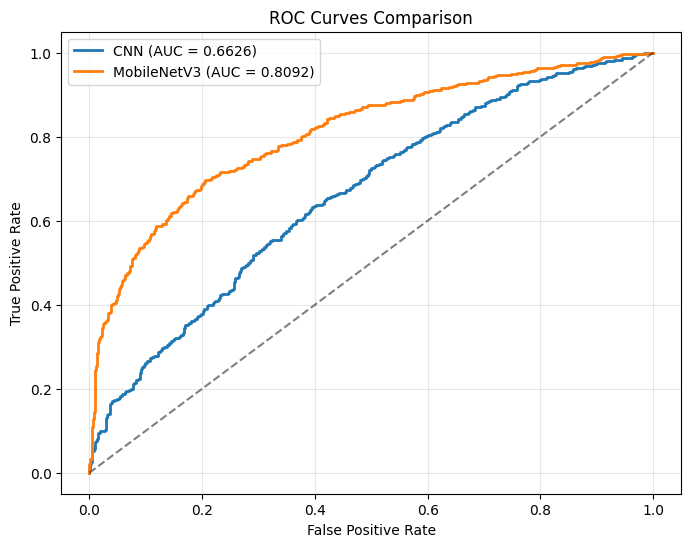

In [16]:
# Metrics Bar Chart
metrics = {
    'Accuracy': [accuracy_score(y_true, cnn_preds), accuracy_score(y_true, mob_preds)],
    'Precision (macro)': [precision_score(y_true, cnn_preds, average='macro'), precision_score(y_true, mob_preds, average='macro')],
    'Recall (macro)': [recall_score(y_true, cnn_preds, average='macro'), recall_score(y_true, mob_preds, average='macro')],
    'F1 (macro)': [f1_score(y_true, cnn_preds, average='macro'), f1_score(y_true, mob_preds, average='macro')]
}

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width/2, [v[0] for v in metrics.values()], width, label='CNN', color='skyblue')
ax.bar(x + width/2, [v[1] for v in metrics.values()], width, label='MobileNet', color='lightgreen')

ax.set_ylabel('Scores')
ax.set_title('Model Performance Comparison')
ax.set_xticks(x)
ax.set_xticklabels(metrics.keys())
ax.legend()
plt.show()

# ROC Curves
fractured_idx = CLASS_NAMES.index("fractured") if "fractured" in CLASS_NAMES else 0
y_binary = (y_true == fractured_idx).astype(int)

fpr_cnn, tpr_cnn, _ = roc_curve(y_binary, cnn_probs[:, fractured_idx])
auc_cnn = roc_auc_score(y_binary, cnn_probs[:, fractured_idx])

fpr_mob, tpr_mob, _ = roc_curve(y_binary, mob_probs[:, fractured_idx])
auc_mob = roc_auc_score(y_binary, mob_probs[:, fractured_idx])

plt.figure(figsize=(8, 6))
plt.plot(fpr_cnn, tpr_cnn, label=f"CNN (AUC = {auc_cnn:.4f})", linewidth=2)
plt.plot(fpr_mob, tpr_mob, label=f"MobileNetV3 (AUC = {auc_mob:.4f})", linewidth=2)
plt.plot([0, 1], [0, 1], "k--", alpha=0.5)
plt.title("ROC Curves Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## 7. Decision Threshold Tuning

**Step Explanation:**
By default, classification uses a `0.5` threshold. In medical imaging, we can manually lower this threshold (e.g., to `0.28`) to increase Recall, ensuring we don't miss potential fractures, even at the cost of slightly more false positives.


 OPTIMIZING THRESHOLD: Baseline CNN 
Default Threshold (0.50) F1 Score: 0.5439
Optimal Threshold (0.35) F1 Score: 0.6753

               precision    recall  f1-score   support

    fractured       0.53      0.93      0.68       730
not_fractured       0.76      0.23      0.35       770

     accuracy                           0.57      1500
    macro avg       0.65      0.58      0.51      1500
 weighted avg       0.65      0.57      0.51      1500



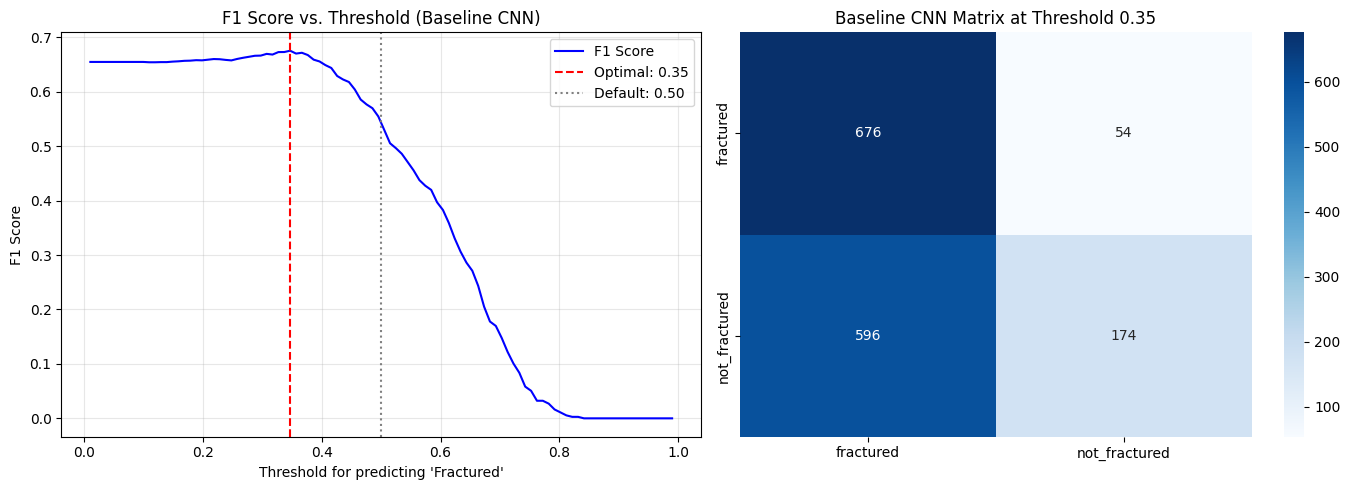


 OPTIMIZING THRESHOLD: MobileNetV3 
Default Threshold (0.50) F1 Score: 0.6961
Optimal Threshold (0.28) F1 Score: 0.7346

               precision    recall  f1-score   support

    fractured       0.65      0.85      0.73       730
not_fractured       0.80      0.56      0.66       770

     accuracy                           0.70      1500
    macro avg       0.72      0.71      0.70      1500
 weighted avg       0.72      0.70      0.70      1500



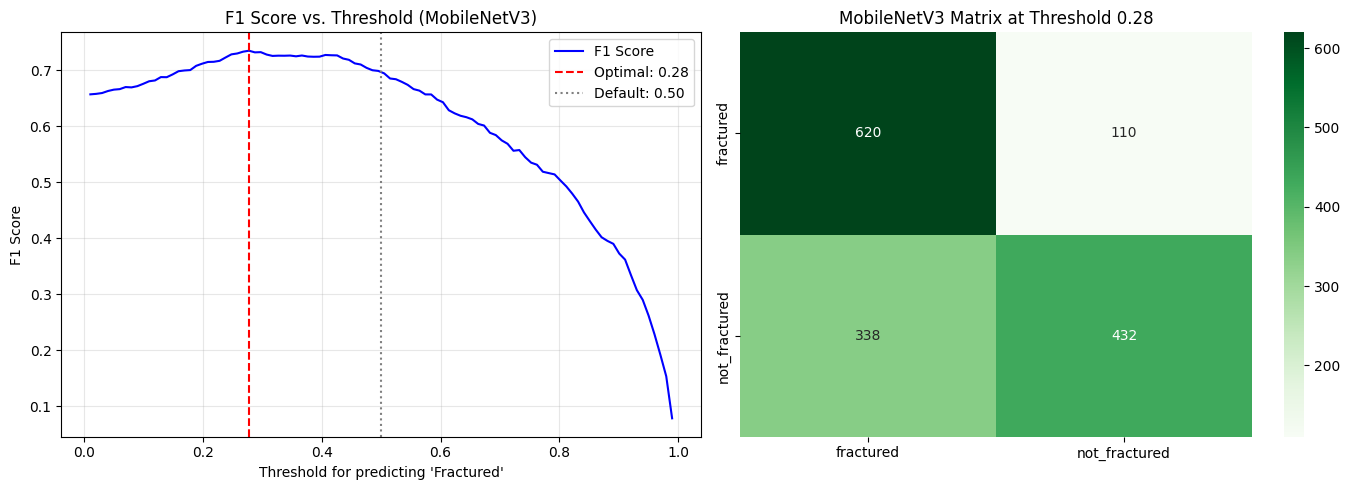

In [18]:
import numpy as np
from sklearn.metrics import f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Identify the index for 'fractured'
fractured_idx = CLASS_NAMES.index("fractured") if "fractured" in CLASS_NAMES else 0
y_true_binary = (y_true == fractured_idx).astype(int)

def evaluate_optimal_threshold(probs, model_name):
    print(f"\n" + "="*50)
    print(f" OPTIMIZING THRESHOLD: {model_name} ")
    print("="*50)
    
    # Extract the raw probabilities for the "fractured" class
    fractured_probs = probs[:, fractured_idx]
    
    # Test thresholds from 0.01 to 0.99
    thresholds = np.linspace(0.01, 0.99, 100)
    f1_scores = []
    
    for thresh in thresholds:
        preds = (fractured_probs >= thresh).astype(int)
        f1_scores.append(f1_score(y_true_binary, preds))
        
    best_idx = np.argmax(f1_scores)
    best_thresh = thresholds[best_idx]
    best_f1 = f1_scores[best_idx]
    
    default_f1 = f1_score(y_true_binary, (fractured_probs >= 0.5).astype(int))
    
    print(f"Default Threshold (0.50) F1 Score: {default_f1:.4f}")
    print(f"Optimal Threshold ({best_thresh:.2f}) F1 Score: {best_f1:.4f}\n")
    
    # Generate predictions using the optimal threshold
    optimal_preds = np.where(fractured_probs >= best_thresh, fractured_idx, 1 - fractured_idx)
    
    print(classification_report(y_true, optimal_preds, target_names=CLASS_NAMES))
    
    # Plotting
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Threshold vs F1 Curve
    axes[0].plot(thresholds, f1_scores, label="F1 Score", color='blue')
    axes[0].axvline(x=best_thresh, color='red', linestyle='--', label=f'Optimal: {best_thresh:.2f}')
    axes[0].axvline(x=0.5, color='gray', linestyle=':', label='Default: 0.50')
    axes[0].set_title(f"F1 Score vs. Threshold ({model_name})")
    axes[0].set_xlabel("Threshold for predicting 'Fractured'")
    axes[0].set_ylabel("F1 Score")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # New Confusion Matrix
    cmap = "Blues" if "CNN" in model_name else "Greens"
    sns.heatmap(confusion_matrix(y_true, optimal_preds), annot=True, fmt='d', cmap=cmap, 
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[1])
    axes[1].set_title(f'{model_name} Matrix at Threshold {best_thresh:.2f}')
    
    plt.tight_layout()
    plt.show()

# Run for both models
evaluate_optimal_threshold(cnn_probs, "Baseline CNN")
evaluate_optimal_threshold(mob_probs, "MobileNetV3")


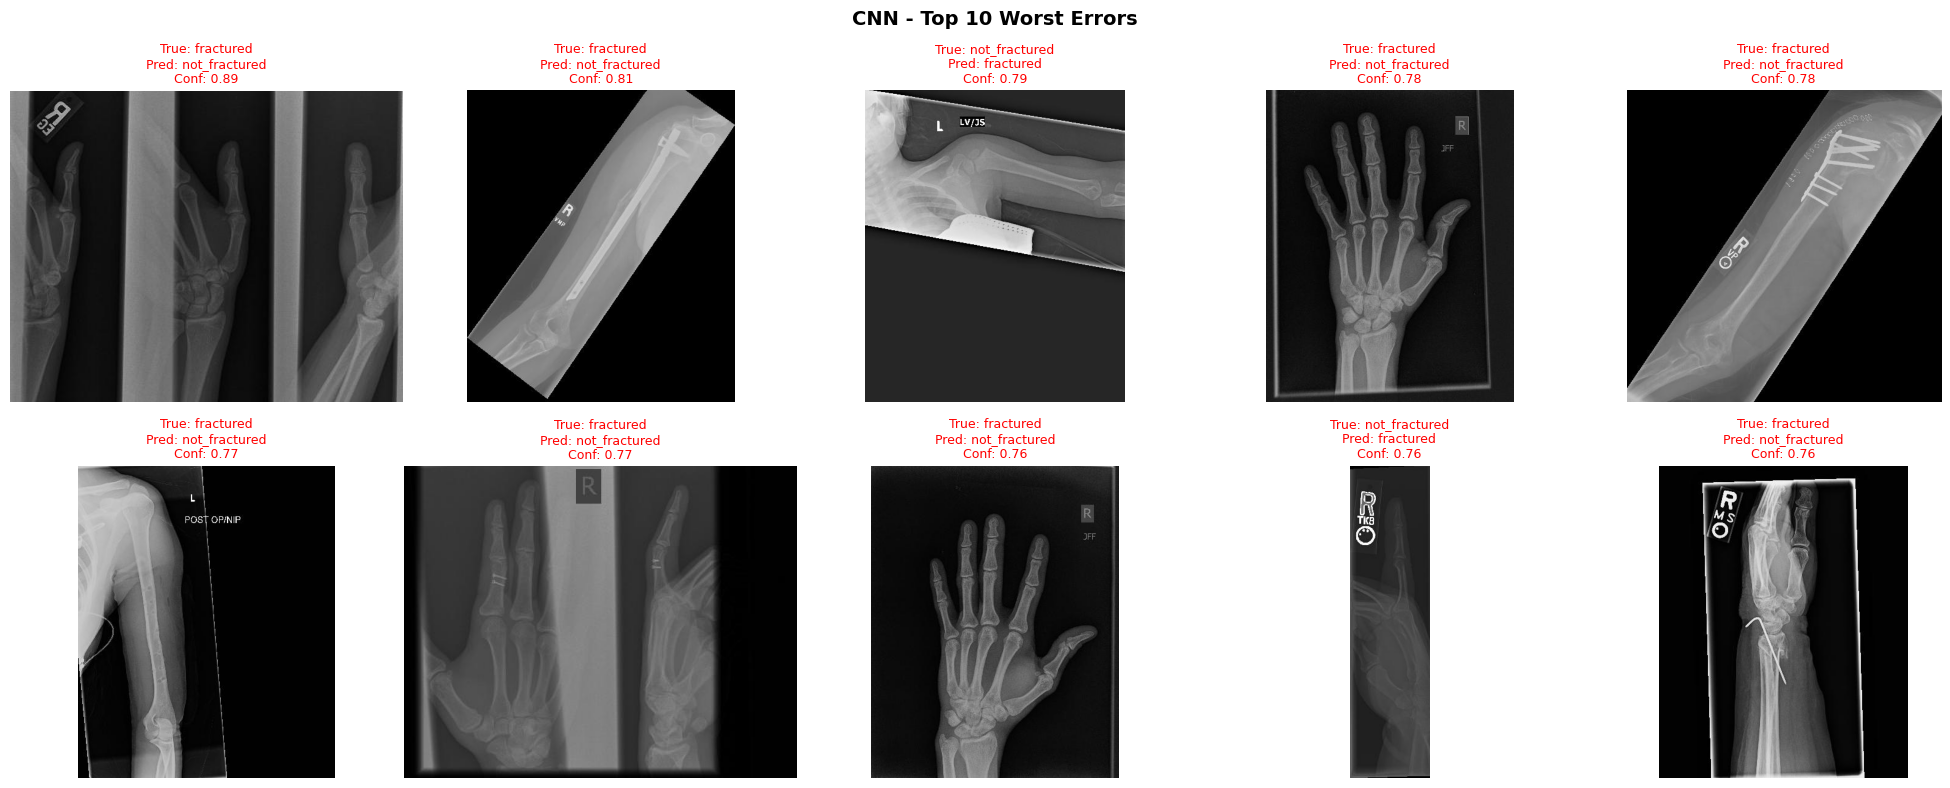

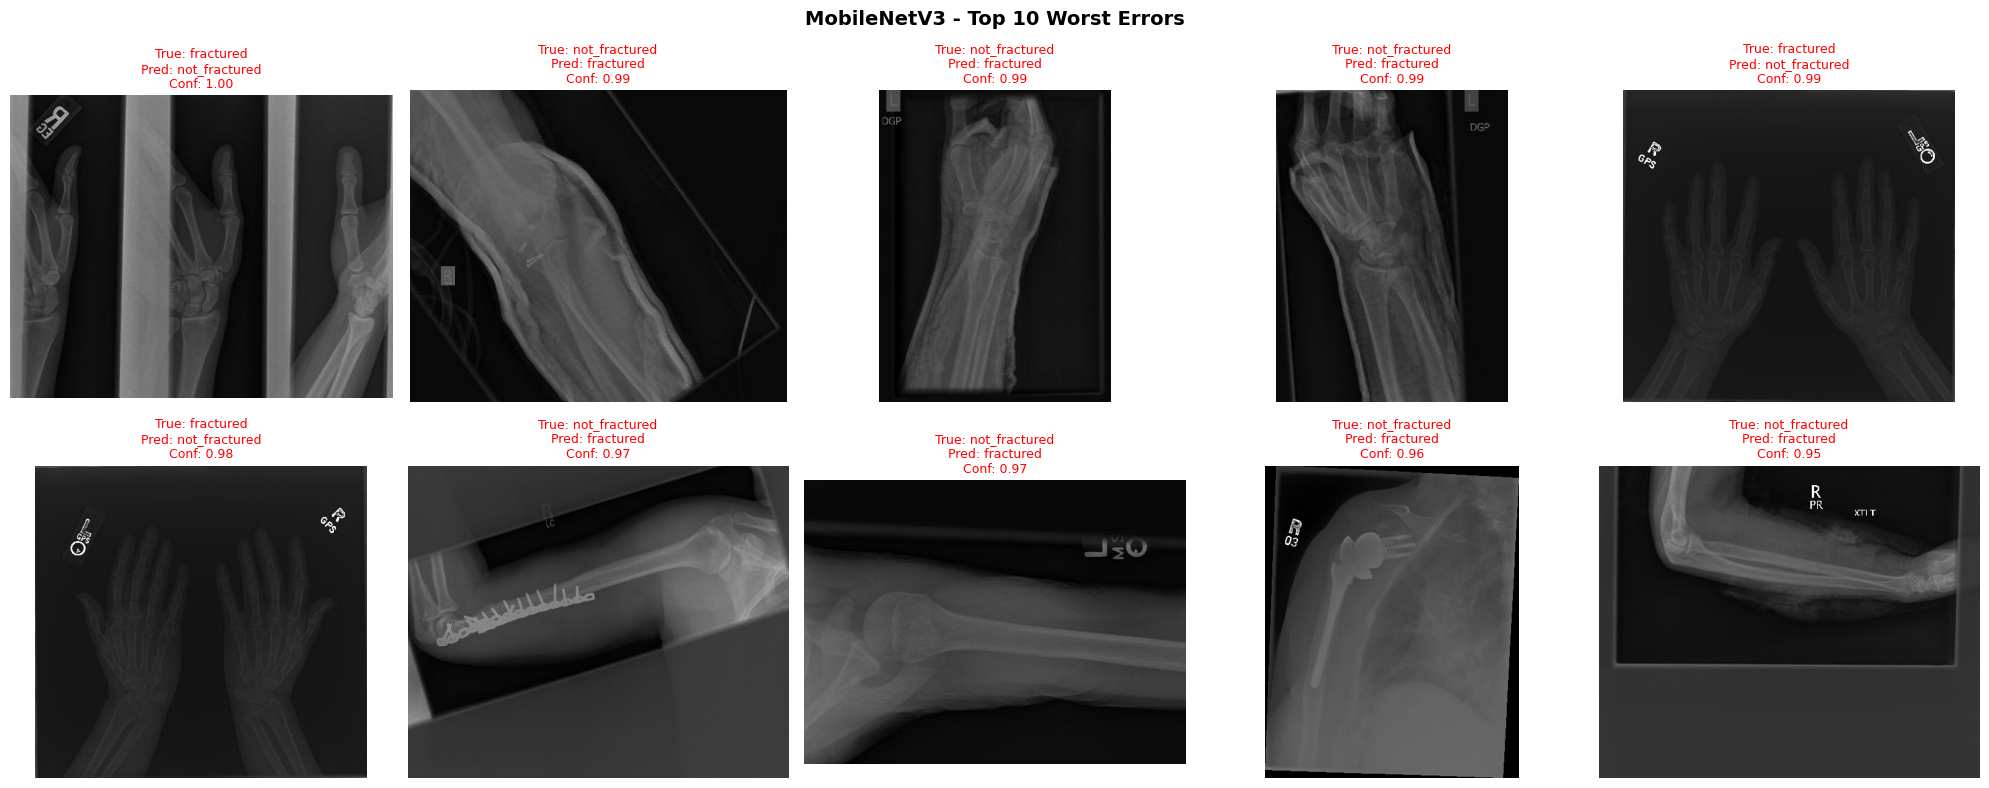

In [20]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Dummy cell - load your test_ds and your best saved models here to get `cnn_probs` and `mob_probs`
# Or carry over variables if running in same session.

def plot_worst_errors(probs, preds, true_labels, paths, class_names, name):
    misclassified_idx = np.where(preds != true_labels)[0]
    if len(misclassified_idx) == 0: return
    
    mis_confidences = [probs[i][preds[i]] for i in misclassified_idx]
    worst_idx = np.argsort(mis_confidences)[::-1][:10]
    
    n_show = min(10, len(worst_idx))
    rows = (n_show + 4) // 5
    fig, axes = plt.subplots(rows, 5, figsize=(20, 4 * rows))
    if rows == 1: axes = [axes]
    
    for ax_i, idx in enumerate(worst_idx[:n_show]):
        sample_idx = misclassified_idx[idx]
        img = Image.open(paths[sample_idx]).convert("RGB")
        row, col = ax_i // 5, ax_i % 5
        axes[row][col].imshow(img)
        axes[row][col].set_title(
            f"True: {class_names[true_labels[sample_idx]]}\n"
            f"Pred: {class_names[preds[sample_idx]]}\n"
            f"Conf: {probs[sample_idx][preds[sample_idx]]:.2f}",
            fontsize=9, color="red"
        )
        axes[row][col].axis("off")
        
    for ax_i in range(n_show, rows * 5):
        axes[ax_i // 5][ax_i % 5].axis("off")
        
    plt.suptitle(f"{name} - Top 10 Worst Errors", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()

plot_worst_errors(cnn_probs, cnn_preds, y_true, test_ds.file_paths, CLASS_NAMES, "CNN")
plot_worst_errors(mob_probs, mob_preds, y_true, test_ds.file_paths, CLASS_NAMES, "MobileNetV3")


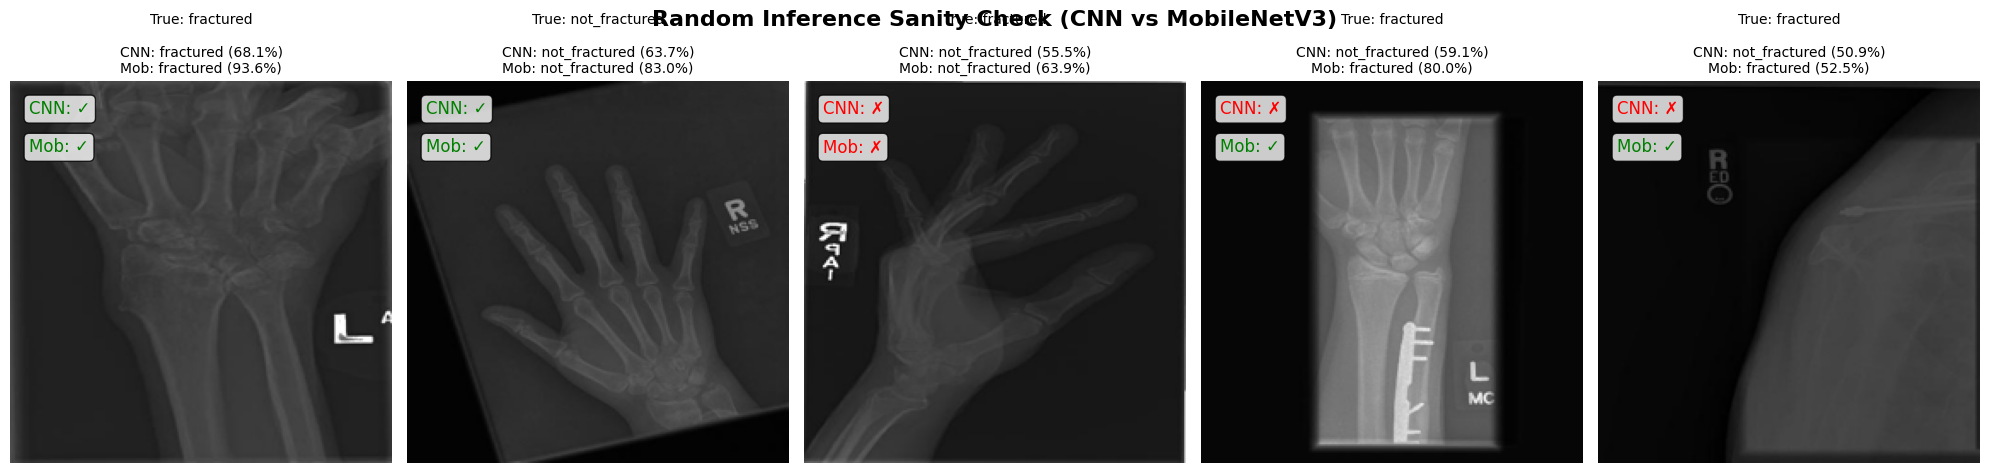

In [23]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import tensorflow as tf

# Grab all image paths from the test directory
all_test_paths = []
for cls in CLASS_NAMES:
    cls_dir = os.path.join(TEST_DIR, cls)
    for fname in os.listdir(cls_dir):
        if fname.endswith(".jpg"):
            all_test_paths.append((os.path.join(cls_dir, fname), cls))

# Select 5 random images
random_samples = random.sample(all_test_paths, 5)

fig, axes = plt.subplots(1, 5, figsize=(20, 5))

for i, (img_path, true_label) in enumerate(random_samples):
    # Load raw image for visualization
    raw_img = Image.open(img_path).resize((IMAGE_SIZE, IMAGE_SIZE))
    img_array = keras.utils.img_to_array(raw_img)
    img_batch = np.expand_dims(img_array, axis=0) # Shape: (1, 224, 224, 3)
    
    # 1. Predict with CNN (expects raw 0-255 pixels, handles rescaling internally)
    cnn_prob = model_cnn.predict(img_batch, verbose=0)[0]
    cnn_pred_class = CLASS_NAMES[np.argmax(cnn_prob)]
    cnn_conf = np.max(cnn_prob) * 100
    
    # 2. Predict with MobileNet (expects preprocessed pixels)
    mob_batch = keras.applications.mobilenet_v3.preprocess_input(np.copy(img_batch))
    mob_prob = model_mob.predict(mob_batch, verbose=0)[0]
    mob_pred_class = CLASS_NAMES[np.argmax(mob_prob)]
    mob_conf = np.max(mob_prob) * 100

    # Plotting
    axes[i].imshow(raw_img)
    axes[i].axis('off')
    
    # Color code the titles (Green = Correct, Red = Incorrect)
    cnn_color = "green" if cnn_pred_class == true_label else "red"
    mob_color = "green" if mob_pred_class == true_label else "red"
    
    title_text = f"True: {true_label}\n\n"
    title_text += f"CNN: {cnn_pred_class} ({cnn_conf:.1f}%)\n"
    title_text += f"Mob: {mob_pred_class} ({mob_conf:.1f}%)"
    
    axes[i].set_title(title_text, color='black', fontsize=10)
    
    # Add colored borders or text box to easily spot errors
    props = dict(boxstyle='round', facecolor='white', alpha=0.8)
    axes[i].text(0.05, 0.95, f"CNN: {'✓' if cnn_pred_class == true_label else '✗'}", 
                 transform=axes[i].transAxes, fontsize=12, color=cnn_color, 
                 verticalalignment='top', bbox=props)
    axes[i].text(0.05, 0.85, f"Mob: {'✓' if mob_pred_class == true_label else '✗'}", 
                 transform=axes[i].transAxes, fontsize=12, color=mob_color, 
                 verticalalignment='top', bbox=props)

plt.suptitle("Random Inference Sanity Check (CNN vs MobileNetV3)", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()
